<a href="https://colab.research.google.com/github/Rishi5105-kashyap/Codtech-tasks/blob/main/codtech_task_2_submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Downloading/Loading IMDB movie reviews dataset...
Loaded 500 IMDB movie reviews.

===== DATASET HEAD =====
                                              Review Sentiment
0  This was an absolutely terrible movie. Don't b...  Negative
1  I have been known to fall asleep during films,...  Negative
2  Mann photographs the Alberta Rocky Mountains i...  Negative
3  This is the kind of film for a snowy Sunday af...  Positive
4  As others have mentioned, all the women that g...  Positive

===== PREPROCESSED TEXT ====
['absolut terribl movi lure christoph walken michael ironsid great actor must simpli worst role histori even great act could redeem movi ridicul storylin movi earli nineti us propaganda piec pathet scene columbian rebel make case revolut maria conchita alonso appear phoni pseudo love affair walken noth pathet emot plug movi devoid real mean disappoint movi like ruin actor like christoph walken good name could bare sit', 'known fall asleep film usual due combin thing includ realli 

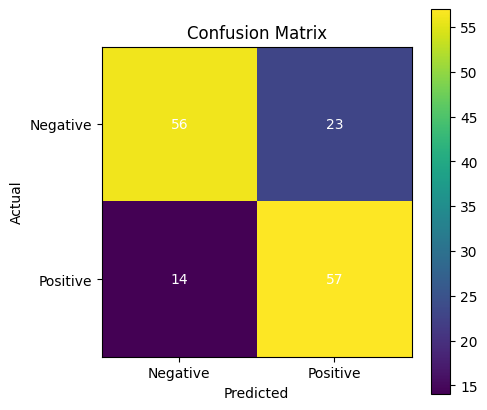


===== CUSTOM REVIEW PREDICTION ====
Review: This product is really good and excellent
Predicted Sentiment: Positive

===== SENTIMENT ANALYSIS PROJECT COMPLETED ====


In [3]:
# ============================================================
# SENTIMENT ANALYSIS USING NLP
# TF-IDF VECTORIZATION + LOGISTIC REGRESSION
# ============================================================

# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Download NLTK stopwords
nltk.download('stopwords')

# ============================================================
# STEP 2: LOAD MOVIE REVIEW DATASET (IMDB as MovieLens typically lacks textual reviews)
# ============================================================

# Note: Standard MovieLens datasets primarily contain ratings and metadata, not textual reviews.
# To demonstrate sentiment analysis on textual reviews as requested, we will use
# a small subset of the IMDB movie reviews dataset, which is a common proxy for movie sentiment analysis.

try:
    # Load the IMDB movie reviews dataset
    # We will take a small subset for demonstration purposes to keep execution fast.
    print("Downloading/Loading IMDB movie reviews dataset...")
    ds = tfds.load('imdb_reviews', split='train', as_supervised=True)

    reviews = []
    sentiments = []

    # Taking a manageable subset of reviews (e.g., first 500)
    for text_tensor, label_tensor in ds.take(500):
        reviews.append(text_tensor.numpy().decode('utf-8'))
        # Map numerical labels (0 for negative, 1 for positive) to string labels
        sentiments.append('Positive' if label_tensor.numpy() == 1 else 'Negative')

    data = {
        'Review': reviews,
        'Sentiment': sentiments
    }

    df = pd.DataFrame(data)
    print(f"Loaded {len(df)} IMDB movie reviews.")

except Exception as e:
    print(f"Could not load IMDB reviews from tensorflow_datasets: {e}")
    print("Falling back to a small, simulated dataset for demonstration.")
    # Fallback to a small simulated dataset if tfds fails or is not preferred
    data = {
        'Review': [
            "The movie was absolutely fantastic, a must-watch!",
            "I really enjoyed the plot and the acting.",
            "Excellent cinematography and a gripping story.",
            "Very satisfied with the film, great experience.",
            "This is one of the best movies of the year.",

            "The movie was terrible, a complete waste of time.",
            "Very boring and predictable storyline.",
            "I hated the ending, it made no sense.",
            "Quality of acting was poor and disappointing.",
            "Worst film I've seen in a long time, waste of money."
        ],
        'Sentiment': [
            'Positive', 'Positive', 'Positive', 'Positive', 'Positive',
            'Negative', 'Negative', 'Negative', 'Negative', 'Negative'
        ]
    }
    df = pd.DataFrame(data)

print("\n===== DATASET HEAD =====")
print(df.head())

# ============================================================
# STEP 3: TEXT PREPROCESSING
# ============================================================

ps = PorterStemmer()

corpus = []

for i in range(len(df)):

    # Remove special characters
    review = re.sub('[^a-zA-Z]', ' ', df['Review'][i])

    # Convert to lowercase
    review = review.lower()

    # Split words
    review = review.split()

    # Remove stopwords and apply stemming
    review = [
        ps.stem(word)
        for word in review
        if word not in stopwords.words('english')
    ]

    # Join words
    review = ' '.join(review)

    corpus.append(review)

print("\n===== PREPROCESSED TEXT ====")
# Print only first 5 preprocessed reviews for brevity
print(corpus[:5])

# ============================================================
# STEP 4: TF-IDF VECTORIZATION
# ============================================================

tfidf = TfidfVectorizer(max_features=1000)

X = tfidf.fit_transform(corpus).toarray()

y = df['Sentiment']

print("\n===== TF-IDF FEATURE SHAPE ====")
print(X.shape)

# ============================================================
# STEP 5: SPLIT DATASET
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("\n===== DATA SPLIT ====")
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

# ============================================================
# STEP 6: TRAIN LOGISTIC REGRESSION MODEL
# ============================================================

model = LogisticRegression()

model.fit(X_train, y_train)

print("\n===== MODEL TRAINED SUCCESSFULLY ====")

# ============================================================
# STEP 7: MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

print("\n===== PREDICTIONS (first 5) ====")
print(y_pred[:5])

# ============================================================
# STEP 8: MODEL EVALUATION
# ============================================================

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\n===== ACCURACY ====")
print("Accuracy:", accuracy)

# Classification Report
print("\n===== CLASSIFICATION REPORT ====")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\n===== CONFUSION MATRIX ====")
print(cm)

# ============================================================
# STEP 9: VISUALIZE CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(5, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0, 1], ['Negative', 'Positive'])
plt.yticks([0, 1], ['Negative', 'Positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center',
                 color='white')

plt.show()

# ============================================================
# STEP 10: TEST CUSTOM REVIEW
# ============================================================

sample_review = "This product is really good and excellent"

# Preprocess
review = re.sub('[^a-zA-Z]', ' ', sample_review)
review = review.lower()
review = review.split()

review = [
    ps.stem(word)
    for word in review
    if word not in stopwords.words('english')
]

review = ' '.join(review)

# TF-IDF transform
review_vector = tfidf.transform([review]).toarray()

# Prediction
prediction = model.predict(review_vector)

print("\n===== CUSTOM REVIEW PREDICTION ====")
print("Review:", sample_review)
print("Predicted Sentiment:", prediction[0])

# ============================================================
# END OF PROJECT
# ============================================================

print("\n===== SENTIMENT ANALYSIS PROJECT COMPLETED ====")
